In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import * 
from ESMCBA import other_utils

In [3]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [4]:
# pd.read_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201all_binders_mhc_flurry.csv')
# mhcflurry = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201all_binders_mhc_flurry.csv')
# mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)
# _ = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201_epitope-A0201_umap.csv')
# sns.set(style="white")
# sns.scatterplot(data=_, x="UMAP_1", y="UMAP_2")
# plt.show()

# Get list of all UMAP files
umap_files = glob.glob('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201*epitope*_umap.csv')
umap_files

['/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201_epitope-A0201_umap.csv']

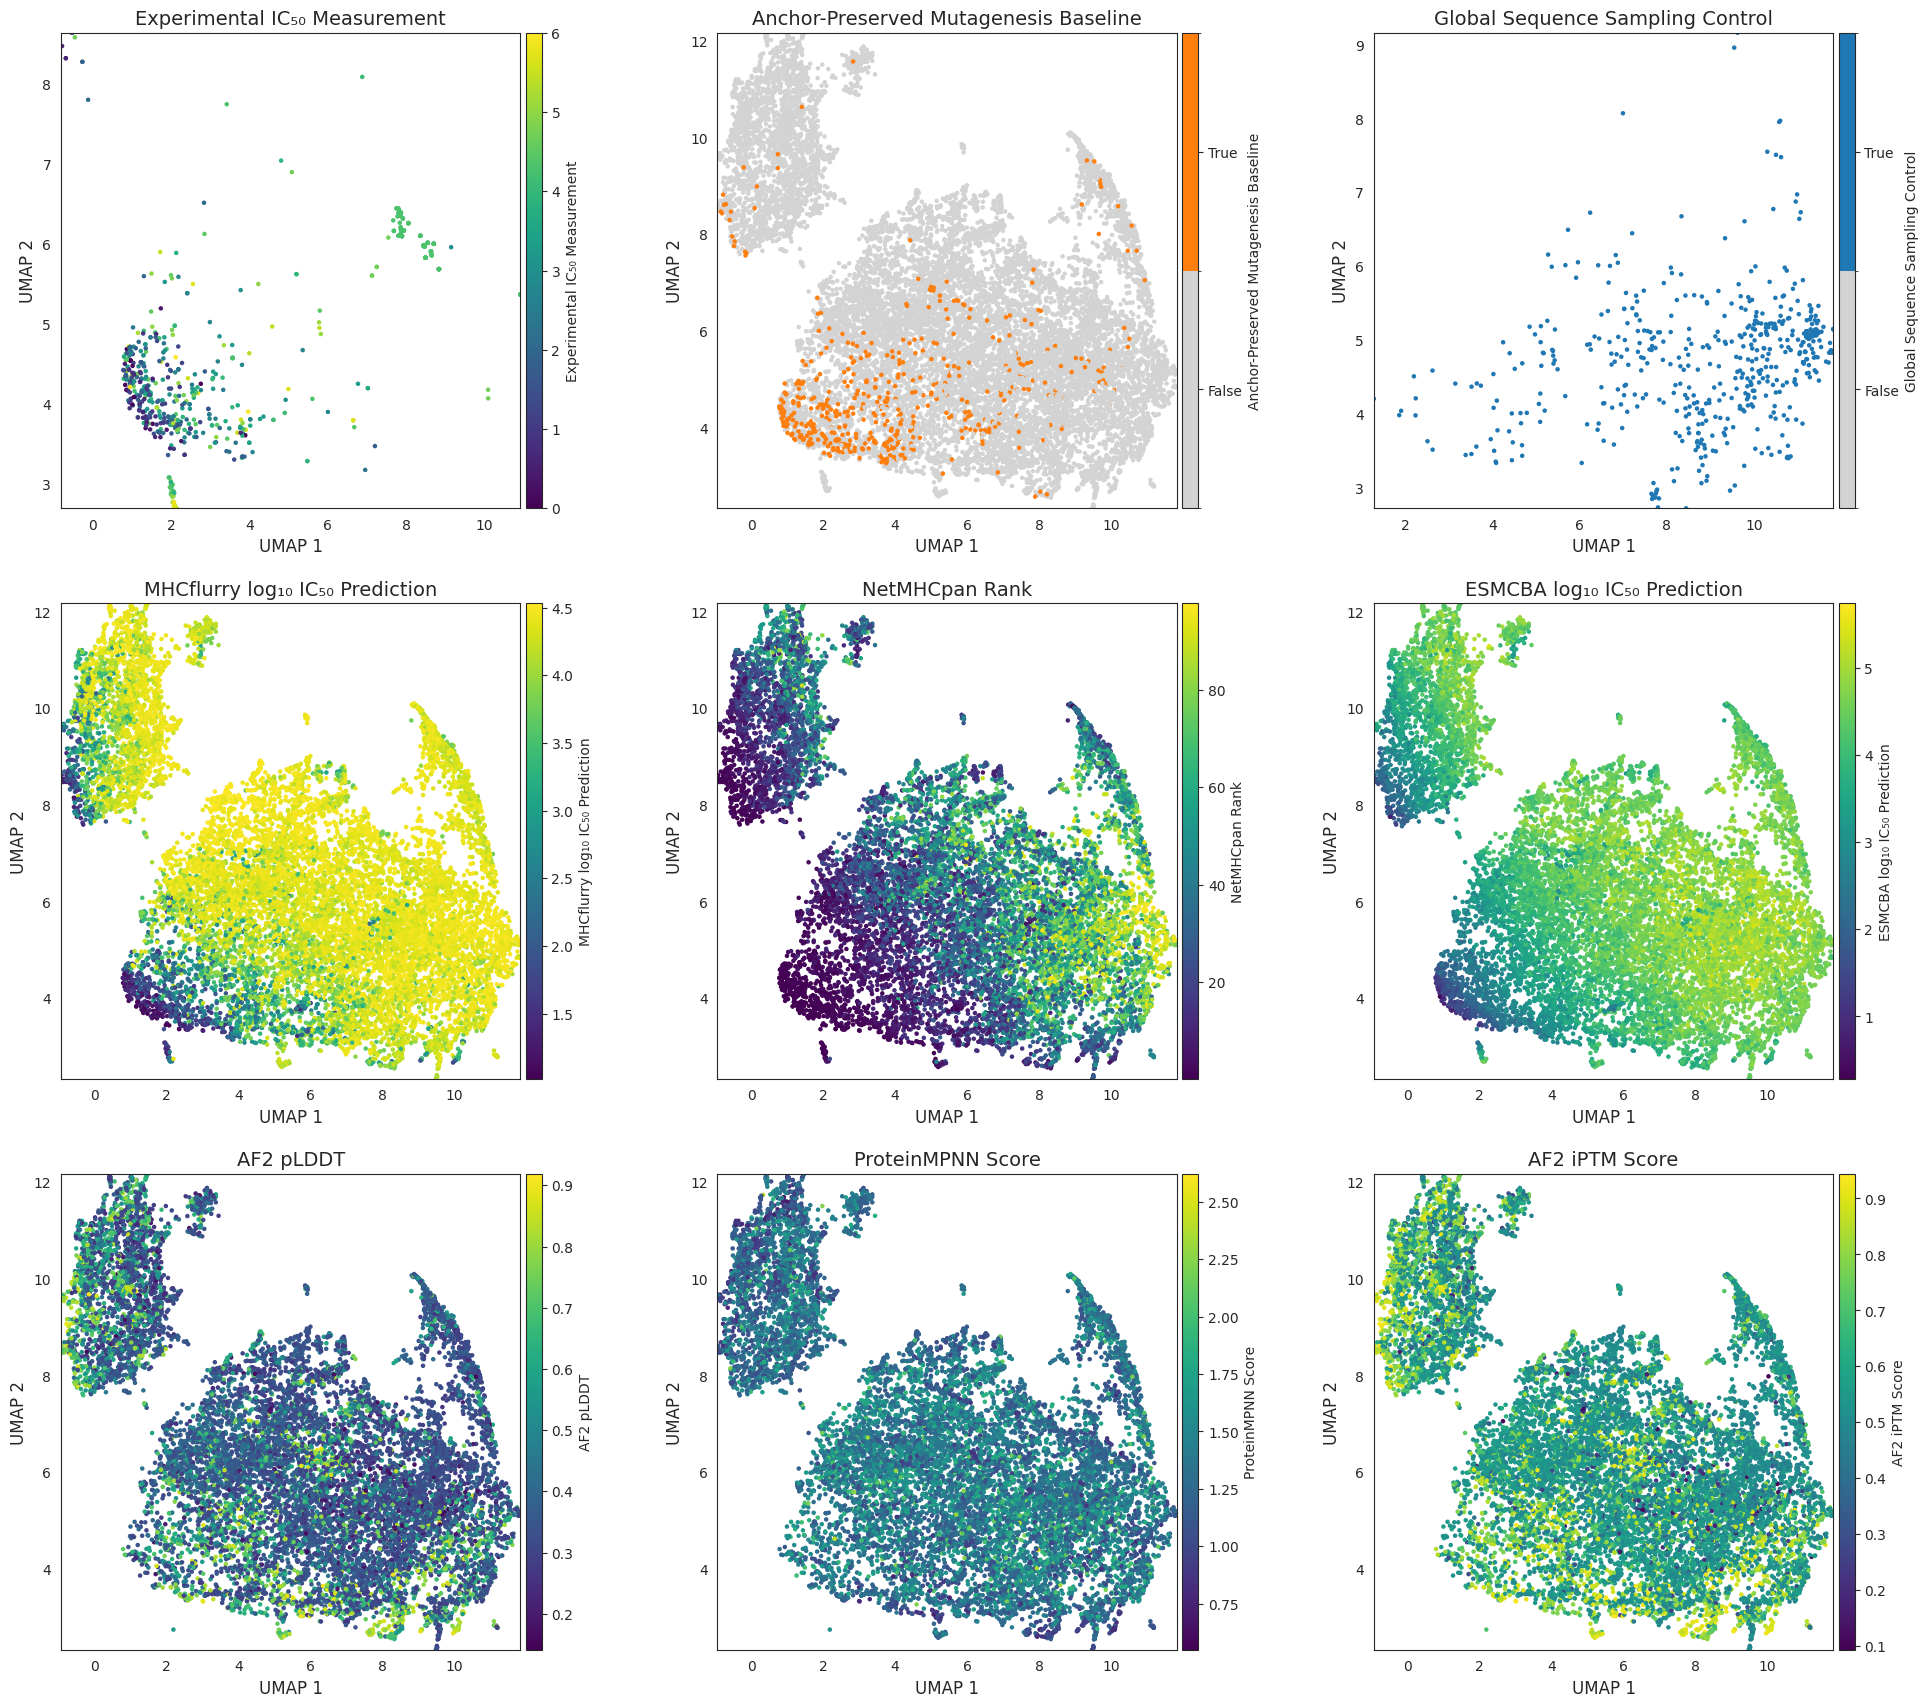

In [20]:
# Load the shared peptide datasets
rfd_peptides_all = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/rdfiffusion_output_peptides.csv')
peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')

# Get list of all UMAP files
umap_files = glob.glob('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201*epitope*_umap.csv')

# Create empty list to collect the merged DataFrames
all_predictions = []

pretty_names = {
    'measured': 'Experimental IC₅₀ Measurement',
    'mhc_log_y': 'MHCflurry log₁₀ IC₅₀ Prediction',
    'BA_Rank': 'NetMHCpan Rank',
    'prediction_x': 'ESMCBA log₁₀ IC₅₀ Prediction',
    'plddt': 'AF2 pLDDT',
    'mpnn': 'ProteinMPNN Score',
    'rmsd': 'AF2 RMSD',
    'i_pae': 'AF2 Interface PAE',
    'i_ptm': 'AF2 iPTM Score',
    'PERMUTATION_TEST' : 'Anchor-Preserved Mutagenesis Baseline',
    'RANDOM_SAMPLED' : 'Global Sequence Sampling Control'
}

sns.set_style("white")

# Now loop over each file
for file in umap_files:
    filename = os.path.basename(file)
    hla = filename.split('_')[0]  # e.g., 'B1501' from 'B1501_epitope-B1501_umap.csv'


    if 'epitope' not in filename:
        continue

    if 'A0201' not in filename:
        continue

    # Load UMAP predictions
    ESCMBA_predictions = pd.read_csv(file)


    mhcflurry = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/{hla}RS_RFD_MAC__mhc_flurry.csv')
    mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)

    # try:
    netmhcspan = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/all_binders_{hla}_netmhc.xls', sep = '\t', header = 1)
    # exscept:

    # if mhc_log.empty:   
    #     print(f"Warning: No mhc_log data for {hla}. Skipping this file.")
    #     continue

    # Subset RFD peptides for this HLA
    rfd_peptides = rfd_peptides_all[rfd_peptides_all['hla_allele'] == hla]

    # Skip if no peptides
    if len(rfd_peptides) == 0:
        continue

    # Subset evaluation set
    peptides_eval = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == f'{hla} epitope']

    # Merge data
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, peptides_eval, on='sequence', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, rfd_peptides, left_on='sequence', right_on='epitope', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, mhcflurry[['peptide','mhc_log','mhcflurry_presentation_score']], left_on='sequence', right_on='peptide', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, netmhcspan[['Peptide','BA_Rank']], left_on='sequence', right_on='Peptide', how='left')    

    # Add a column for HLA for traceability
    ESCMBA_predictions['HLA'] = hla

    random_sampled = pd.read_csv('9mers_esm2.csv')
    random_sampled['RANDOM_SAMPLED'] = True

    ESCMBA_predictions = pd.merge(left=ESCMBA_predictions, right=random_sampled, on='sequence', how='left')

    ESCMBA_predictions['PERMUTATION_TEST'] = (
    ESCMBA_predictions['RANDOM_SAMPLED'].isna() & ESCMBA_predictions['BA_Rank'].isna()
)

    # Append this merged df to list
    all_predictions.append(ESCMBA_predictions)

    # ---- (your plotting code stays exactly the same) ----
    hue_columns = [
        'measured', 'PERMUTATION_TEST', 'RANDOM_SAMPLED', 'mhc_log_y', 'BA_Rank',
        'prediction_x', 'plddt', 'mpnn', 'i_ptm'
    ]

    n_cols = 3
    n_rows = (len(hue_columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 7 * n_rows))
    axes = axes.flatten()

import matplotlib as mpl
from matplotlib.colors import ListedColormap

# define discrete colormaps
perm_cmap   = ListedColormap(['lightgray', 'tab:orange'])
random_cmap = ListedColormap(['lightgray', 'tab:blue'])

for idx, hue_var in enumerate(hue_columns):
    ax = axes[idx]
    subset = ESCMBA_predictions[ESCMBA_predictions[hue_var].notna()]

    # choose cmap and norm
    if hue_var == 'PERMUTATION_TEST':
        cmap = perm_cmap
        norm = mpl.colors.BoundaryNorm([0, 0.5, 1], perm_cmap.N)
    elif hue_var == 'RANDOM_SAMPLED':
        cmap = random_cmap
        norm = mpl.colors.BoundaryNorm([0, 0.5, 1], random_cmap.N)
    else:
        cmap = 'viridis'
        norm = None

    points = ax.scatter(
        subset['UMAP_1'],
        subset['UMAP_2'],
        c=subset[hue_var],
        cmap=cmap,
        norm=norm,
        s=5,
        edgecolor=None
    )

    title_str = pretty_names.get(hue_var, hue_var)
    ax.set_title(title_str, fontsize=14)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_xlim(subset['UMAP_1'].min(), subset['UMAP_1'].max())
    ax.set_ylim(subset['UMAP_2'].min(), subset['UMAP_2'].max())

    cbar = fig.colorbar(
        points,
        ax=ax,
        orientation='vertical',
        pad=0.01,
        aspect=30
    )
    cbar.set_label(title_str, fontsize=10)

    # if discrete baseline, show True/False ticks
    if hue_var in ('PERMUTATION_TEST', 'RANDOM_SAMPLED'):
        cbar.set_ticks([0.25, 0.75])
        cbar.set_ticklabels(['False', 'True'])

    # plt.tight_layout()
    # plt.suptitle(f'UMAP analysis for {filename}', fontsize=16, y=1.02)

    # # save figures as PDF
output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f'{hla}_2UMAP_analysis.pdf')
plt.savefig(output_path, bbox_inches='tight')
plt.show()
# # plt.tight_layout()
# plt.show()


# ====> AFTER the loop finishes:
# Concatenate all merged DataFrames together
final_df = pd.concat(all_predictions, ignore_index=True)

# # Save it to CSV (or pickle, up to you)
# final_df.to_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/ALL_MERGED_UMAP_predictions.csv', index=False)

# print(f"✅ Saved merged UMAP dataframe with shape {final_df.shape}")


In [21]:
ESCMBA_predictions[
                    (~ESCMBA_predictions['plddt'].notna()) &  #NOT RFDIFFUSION
                    (ESCMBA_predictions['PERMUTATION_TEST'] == True) &  #NOT PERMUTATION TEST 
                    (~ESCMBA_predictions['RANDOM_SAMPLED'].notna()) &
                    (~ESCMBA_predictions['measured'].notna())
                    ] #NOTRANDOMLY SAMPLED ?? 

,sequence,prediction_x,UMAP_1,UMAP_2,prediction_y,measured,Model,HLA,allele_x,allele_y,...,hla_allele,epitope,length_y,peptide_y,mhc_log_y,mhcflurry_presentation_score_y,Peptide_y,BA_Rank,RANDOM_SAMPLED,PERMUTATION_TEST
14093,PAQCKTSPLK,4.474410,7.986503,6.428309,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,PAQCKTSPLK,4.448613,0.003720,NaN,NaN,NaN,True
14094,SANWHTFLFK,4.362711,4.969127,6.851382,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,SANWHTFLFK,4.295785,0.036130,NaN,NaN,NaN,True
14095,EAYKVYFLEK,4.208637,5.895364,6.548116,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,EAYKVYFLEK,4.440074,0.037926,NaN,NaN,NaN,True
14096,DAMSVENQMK,4.725316,7.080422,6.278985,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,DAMSVENQMK,4.376862,0.007667,NaN,NaN,NaN,True
14097,YAHVSRTKCK,4.871889,7.178083,5.904228,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,YAHVSRTKCK,4.488737,0.003480,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14588,KVGPKTQML,3.926508,7.449185,3.578744,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
14589,VVQSREKYL,4.210352,6.488471,3.942997,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
14590,MVKKLPYTL,3.524639,-0.207758,9.380263,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
14591,AVSTTHQKL,3.778776,6.617670,3.969872,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [22]:
ESCMBA_predictions['length_x'] = ESCMBA_predictions['sequence'].apply(len)

No sequences found for length 8


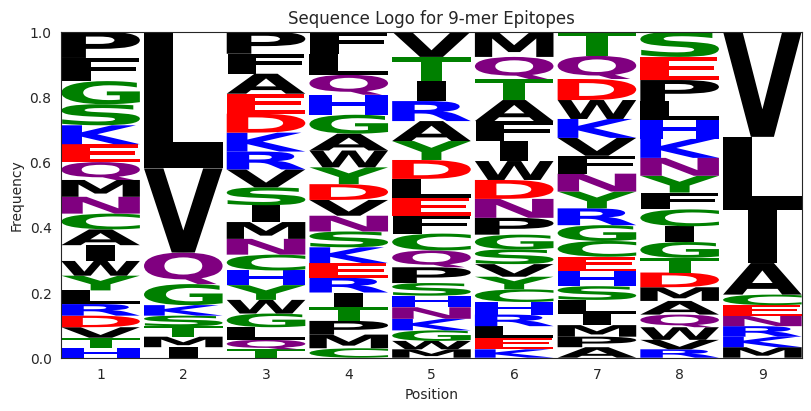

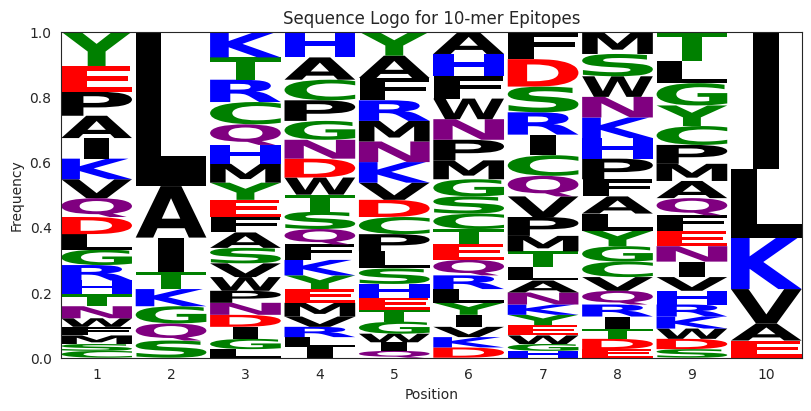

No sequences found for length 11
No sequences found for length 12
No sequences found for length 13
No sequences found for length 14


In [23]:
import logomaker
import os

# Define standard amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Output directory for saving figures
output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)

# Loop through epitope lengths
for n in range(8, 15):
    # Filter sequences from ESCMBA_predictions
    sequences = ESCMBA_predictions[
        # (ESCMBA_predictions['plddt'] >= 0.8) &  # High-confidence predictions
        (ESCMBA_predictions['PERMUTATION_TEST'] == True) &  # Not permutation-tested
        (ESCMBA_predictions['RANDOM_SAMPLED'].isna()) &  # Not randomly sampled
        (ESCMBA_predictions['length_x'] == n)  # Length of interest

    ]['sequence'].to_list()

    # print(sequences)
    # Only proceed if sequences are found
    if sequences:
        # Initialize frequency matrix
        freq_matrix = np.zeros((n, len(amino_acids)))

        # Compute frequency for each position and amino acid
        for seq in sequences:
            if len(seq) == n:  # Ensure sequence length matches
                for j, aa in enumerate(seq):
                    if aa in amino_acids:
                        freq_matrix[j, amino_acids.index(aa)] += 1

        # Normalize by number of sequences
        if len(sequences) > 0:
            freq_matrix /= len([seq for seq in sequences if len(seq) == n])

        # Create DataFrame for logomaker
        freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

        # Generate sequence logo
        logomaker.Logo(freq_df, ax=ax, color_scheme='chemistry')
        ax.set_xlabel("Position")
        ax.set_ylabel("Frequency")
        ax.set_xticks(range(n))
        ax.set_xticklabels(range(1, n + 1))
        ax.set_title(f"Sequence Logo for {n}-mer Epitopes")

        # Save figure
        output_path = os.path.join(output_dir, f'seqlogo_{n}_random_peptides_mer.pdf')
        plt.savefig(output_path, bbox_inches='tight')
        plt.show()
    else:
        print(f"No sequences found for length {n}")

    # Close figure to free memory
    plt.close(fig)

In [24]:
ESCMBA_predictions.columns

Index(['sequence', 'prediction_x', 'UMAP_1', 'UMAP_2', 'prediction_y',
       'measured', 'Model', 'HLA', 'allele_x', 'allele_y', 'peptide_x',
       'mhcflurry_affinity', 'mhcflurry_affinity_percentile',
       'mhcflurry_processing_score', 'mhcflurry_presentation_score_x',
       'mhcflurry_presentation_percentile', 'mhc_log_x', 'Peptide_x',
       'netmhc_log', 'length_x', 'allele', 'Unnamed: 0', 'design', 'n', 'mpnn',
       'plddt', 'i_ptm', 'i_pae', 'rmsd', 'seq', 'RUN', 'PDB', 'CREATED',
       'pdb_id', 'title', 'method', 'resolution', 'release_date',
       'revision_date', 'hla_allele', 'epitope', 'length_y', 'peptide_y',
       'mhc_log_y', 'mhcflurry_presentation_score_y', 'Peptide_y', 'BA_Rank',
       'RANDOM_SAMPLED', 'PERMUTATION_TEST'],
      dtype='object')

Index(['sequence', 'prediction_x', 'UMAP_1', 'UMAP_2', 'prediction_y',
       'measured', 'Model', 'HLA', 'allele_x', 'allele_y', 'peptide_x',
       'mhcflurry_affinity', 'mhcflurry_affinity_percentile',
       'mhcflurry_processing_score', 'mhcflurry_presentation_score_x',
       'mhcflurry_presentation_percentile', 'mhc_log_x', 'Peptide_x',
       'netmhc_log', 'length_x', 'allele', 'Unnamed: 0', 'design', 'n', 'mpnn',
       'plddt', 'i_ptm', 'i_pae', 'rmsd', 'seq', 'RUN', 'PDB', 'CREATED',
       'pdb_id', 'title', 'method', 'resolution', 'release_date',
       'revision_date', 'hla_allele', 'epitope', 'length_y', 'peptide_y',
       'mhc_log_y', 'mhcflurry_presentation_score_y', 'Peptide_y', 'BA_Rank',
       'RANDOM_SAMPLED', 'PERMUTATION_TEST'],
      dtype='object')

In [82]:
sequences

[]

In [41]:
#if in that list is random permutations test 

# final_df[final_df['RANDOM_SAMPLED'].isna() & final_df['BA_Rank'].isna()]

final_df['PERMUTATION_TEST'] = final_df['RANDOM_SAMPLED'].isna() & final_df['BA_Rank'].isna()

In [43]:
final_df[final_df['PERMUTATION_TEST'] == True]

,sequence,prediction_x,UMAP_1,UMAP_2,prediction_y,measured,Model,HLA,allele_x,allele_y,...,hla_allele,epitope,length_y,peptide_y,mhc_log_y,mhcflurry_presentation_score_y,Peptide_y,BA_Rank,RANDOM_SAMPLED,PERMUTATION_TEST
14093,PAQCKTSPLK,4.483980,-0.084474,7.891784,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,PAQCKTSPLK,4.448613,0.003720,NaN,NaN,NaN,True
14094,SANWHTFLFK,4.358413,3.023318,7.191786,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,SANWHTFLFK,4.295785,0.036130,NaN,NaN,NaN,True
14095,EAYKVYFLEK,4.204449,1.423616,7.757379,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,EAYKVYFLEK,4.440074,0.037926,NaN,NaN,NaN,True
14096,DAMSVENQMK,4.737109,-0.054024,8.176024,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,DAMSVENQMK,4.376862,0.007667,NaN,NaN,NaN,True
14097,YAHVSRTKCK,4.895571,0.853154,8.101620,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,YAHVSRTKCK,4.488737,0.003480,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221088,CLYDHHHYL,1.154427,10.075665,10.562528,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,CLYDHHHYL,1.059880,0.961593,NaN,NaN,NaN,True
221089,MLGMTWEIL,2.984411,6.903676,1.115666,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,MLGMTWEIL,2.786783,0.131191,NaN,NaN,NaN,True
221090,FLYSWIFCL,0.660892,10.604637,10.401543,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,FLYSWIFCL,1.051430,0.898110,NaN,NaN,NaN,True
221091,SLGVQGKEL,3.401926,3.401517,10.670651,NaN,NaN,NaN,A0201,NaN,NaN,...,NaN,NaN,NaN,SLGVQGKEL,3.077837,0.093694,NaN,NaN,NaN,True


In [11]:
training_data = pd.DataFrame()

for formatted_HLA in ['A0201', 'B1501', 'B5701']:
    
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"

    train_fasta = pd.read_csv(train_fasta, header=None)
    train_fasta.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                        'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    train_fasta['HLA'] = formatted_HLA
    train_fasta = train_fasta[['sequence','HLA']]
    training_data = pd.concat([training_data, train_fasta])

In [26]:
import numpy as np, pandas as pd
from scipy.spatial.distance import jensenshannon
from Bio import pairwise2

# ------------------------------------------------------------
# helper functions (unchanged)
# ------------------------------------------------------------
def build_pwm(seqs, length=9):
    aa = "ACDEFGHIKLMNPQRSTVWY"
    pwm = np.zeros((20, length))
    for s in seqs:
        if len(s) != length:
            continue
        for i, res in enumerate(s):
            if res not in aa:
                break
            pwm[aa.index(res), i] += 1
    pwm = pwm / pwm.sum(axis=0, keepdims=True)
    return pwm

def max_identity(query, ref_set):
    if len(query) in {len(r) for r in ref_set}:      # fast exact-length check
        return max(sum(q == r for q, r in zip(query, ref)) / len(query)
                   for ref in ref_set)
    best = 0
    for ref in ref_set:
        aln = pairwise2.align.localms(query, ref, 1, 0, -10, -10,
                                      one_alignment_only=True)
        if aln:
            best = max(best, aln[0][2] / max(len(query), len(ref)))
    return best

# ------------------------------------------------------------
# parameters
# ------------------------------------------------------------
L            = 9          # peptide length for PWM
N_PER_GROUP  = 4000       # sample cap per allele
RNG          = np.random.default_rng(0)

# ------------------------------------------------------------
# split sets (must have 'sequence' and 'HLA' columns)
# ------------------------------------------------------------
train_df = training_data[['sequence', 'HLA']].dropna()
rfdiff   = final_df[final_df['measured'].isna()][['sequence', 'HLA']]

allele_results   = []
identity_records = []     # optional: for histogram later

for allele, gen_sub in rfdiff.groupby('HLA'):
    # -----------------------------------------------------------------
    # sample up to N_PER_GROUP sequences per set (without replacement)
    # -----------------------------------------------------------------
    gen_sample = gen_sub.sample(min(len(gen_sub), N_PER_GROUP),
                                random_state=RNG.integers(1e9))['sequence']
    
    train_sub  = train_df[train_df['HLA'] == allele]
    if train_sub.empty:
        continue                                    # no training peptides for this allele
    train_sample = train_sub.sample(min(len(train_sub), N_PER_GROUP),
                                    random_state=RNG.integers(1e9))['sequence']

    # -----------------------------------------------------------------
    # PWM + Jensen–Shannon divergence
    # -----------------------------------------------------------------
    pwm_train = build_pwm(train_sample, length=L)
    pwm_gen   = build_pwm(gen_sample,  length=L)
    eps       = 1e-9
    jsd_bits  = jensenshannon(pwm_train.flatten() + eps,
                              pwm_gen.flatten()   + eps,
                              base=2)

    # -----------------------------------------------------------------
    # optional: max-identity distribution for this allele
    # -----------------------------------------------------------------
    ref_set = set(train_sample)        # exact lengths only (all 9-mers)
    ids     = [max_identity(p, ref_set) for p in gen_sample]
    identity_records.extend([(allele, v) for v in ids])

    allele_results.append({
        'HLA': allele,
        'n_train': len(train_sample),
        'n_gen':   len(gen_sample),
        'JSD_bits': jsd_bits
    })

# ------------------------------------------------------------
# tidy outputs
# ------------------------------------------------------------
allele_jsd = pd.DataFrame(allele_results).sort_values('JSD_bits')
print(allele_jsd.head())

id_df = pd.DataFrame(identity_records, columns=['HLA', 'max_identity'])
# id_df.to_csv('identity_per_allele_sampled.csv', index=False)  # if you need it

# global stats you might quote
median_jsd = allele_jsd['JSD_bits'].median()
print(f"Median per-allele JSD (sample ≤{N_PER_GROUP} per set): {median_jsd:.3f} bits")


     HLA  n_train  n_gen  JSD_bits
0  A0201     4000   4000  0.406896
1  B1501     3815   3936  0.412294
2  B5701     2293   2032  0.462811
Median per-allele JSD (sample ≤4000 per set): 0.412 bits


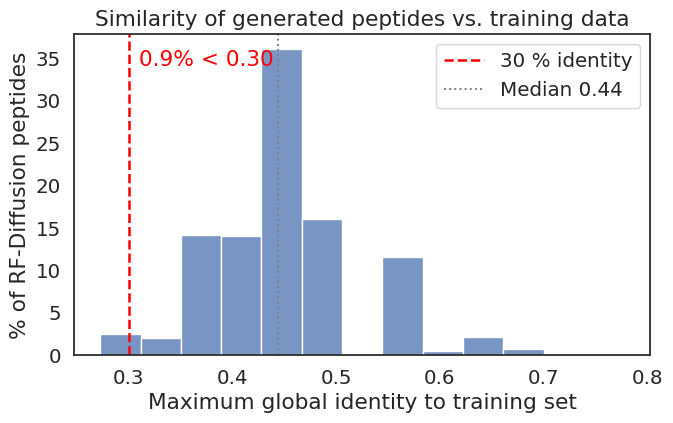

In [29]:

sns.set(style="white", font_scale=1.3)

fig, ax = plt.subplots(figsize=(7, 4.5))

# histogram with percent y-axis
sns.histplot(id_df['max_identity'],
             bins=13,
             stat='percent',
             edgecolor=None,
             ax=ax)

# 30 % similarity threshold
ax.axvline(0.30, ls='--', lw=1.8, color='red',
           label='30 % identity')

pct = (id_df['max_identity'] < 0.30).mean() * 100
ax.text(0.31, ax.get_ylim()[1]*0.9,
        f'{pct:0.1f}% < 0.30', color='red')
         
med = id_df['max_identity'].median()
ax.axvline(med, color='grey', ls=':', lw=1.4, label=f'Median {med:0.2f}')


ax.set_xlabel('Maximum global identity to training set')
ax.set_ylabel('% of RF-Diffusion peptides')
ax.set_title('Similarity of generated peptides vs. training data')
ax.legend(frameon=True)



plt.tight_layout()
output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f'SIMILARITY.pdf')
plt.savefig(output_path, bbox_inches='tight')


# plt.tight_layout()
plt.show()


In [28]:

# ------------------------------------------------------------------
def pct_below(series, thresh=0.30):
    return 100 * (series < thresh).mean()

summary = (id_df
           .groupby('HLA')['max_identity']
           .agg(n_pep='size',
                median_id='median',
                pct_lt_0_30=pct_below)
           .reset_index()
           .sort_values('median_id'))

# ------------------------------------------------------------------
# 2.  Export LaTeX (booktabs + siunitx)
# ------------------------------------------------------------------
latex_table = summary.to_latex(index=False,
                               float_format="%.2f",
                               column_format="l S[table-format=4.0] S[table-format=1.2] S[table-format=2.1]",
                               header=["Allele",
                                       "Peptides",
                                       "Median\nidentity",
                                       "%\n< 0.30"],
                               caption=("Per-allele similarity of RF Diffusion peptides "
                                        "to training set (9-mers, n ≤ 2 000 sampled each)."),
                               label="tab:identity_per_allele",
                               longtable=False,
                               escape=False,
                               bold_rows=False)

print(latex_table)


\begin{table}
\caption{Per-allele similarity of RF Diffusion peptides to training set (9-mers, n ≤ 2 000 sampled each).}
\label{tab:identity_per_allele}
\begin{tabular}{l S[table-format=4.0] S[table-format=1.2] S[table-format=2.1]}
\toprule
Allele & Peptides & Median
identity & %
< 0.30 \\
\midrule
A0201 & 4000 & 0.44 & 0.30 \\
B1501 & 3936 & 0.44 & 0.89 \\
B5701 & 2032 & 0.44 & 2.12 \\
\bottomrule
\end{tabular}
\end{table}



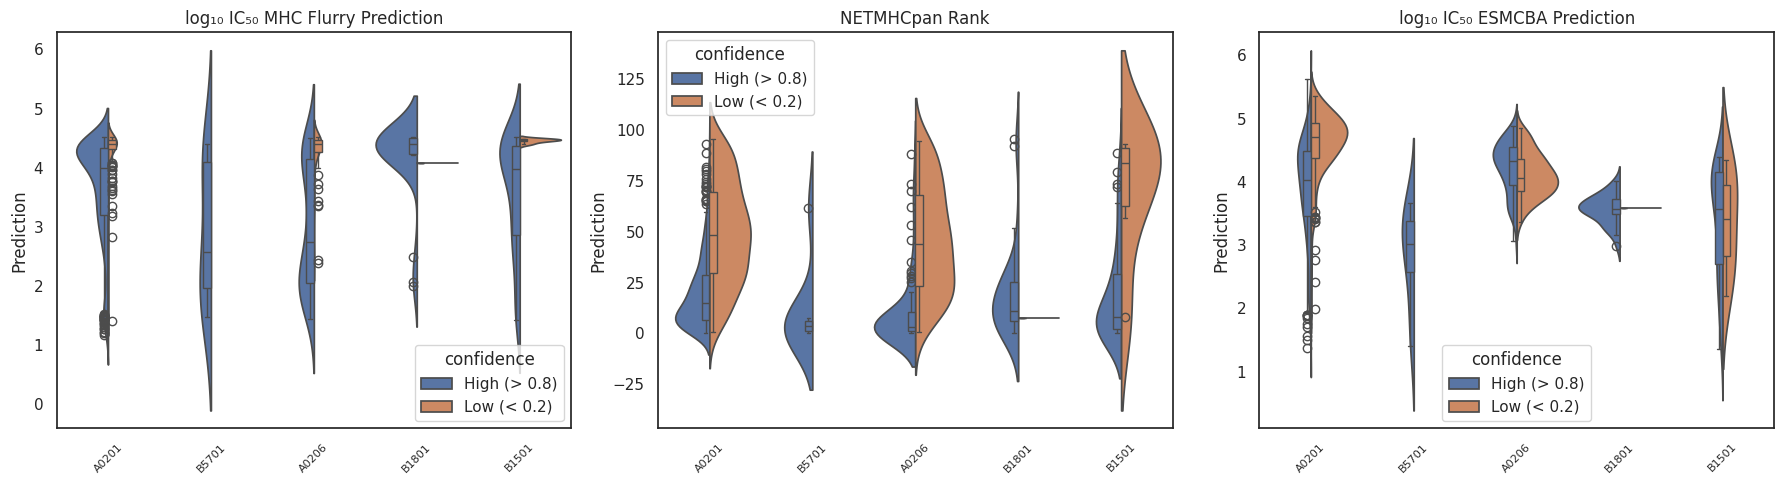

In [ ]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# ----------------------------------------
# 0.  final_df must already exist
# ----------------------------------------
# e.g.:
# final_df = pd.read_pickle("ALL_MERGED_UMAP_predictions.pkl")

metrics = ['mhc_log_y', 'BA_Rank', 'prediction_x']
pretty_name = {
    'mhc_log_y':    'log₁₀ IC₅₀ MHC Flurry Prediction',
    'BA_Rank':      'NETMHCpan Rank',
    'prediction_x': 'log₁₀ IC₅₀ ESMCBA Prediction'
}

# ----------------------------------------
# 1.  build plotting table — *only* rows <0.2 or >0.8
# ----------------------------------------
df_plot = (
    final_df
      .loc[:, metrics + ['plddt', 'HLA']]
      .dropna(subset=metrics + ['plddt', 'HLA'])
      .query('plddt > 0.8 or plddt < 0.2')              # keep only extremes
      .assign(confidence=lambda d:
              np.where(d['plddt'] > 0.8, 'High (> 0.8)', 'Low (< 0.2)'))
)

# (optional) cap at the 10 most frequent HLAs for readability
top_hlas = df_plot['HLA'].value_counts().head(10).index
df_plot  = df_plot[df_plot['HLA'].isin(top_hlas)]

# melt to long format
df_long = df_plot.melt(id_vars=['HLA', 'confidence'],
                       value_vars=metrics,
                       var_name='metric',
                       value_name='value')

# ----------------------------------------
# 2.  violin + box plots
# ----------------------------------------
sns.set(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    subset = df_long[df_long['metric'] == metric]

    sns.violinplot(data=subset,
                   x='HLA', y='value', hue='confidence',
                   split=True, inner=None, dodge=True,
                   ax=ax, legend=True)

    sns.boxplot(data=subset,
                x='HLA', y='value', hue='confidence',
                width=0.15, #, showfliers=False,
                # showcaps=True, dodge=True,
                ax=ax, legend=False)
                # boxprops={'zorder': 3}, linewidth=1)

    ax.set_title(pretty_name[metric])
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Prediction')

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
# leg = fig.legend(handles[:2], ['Low (< 0.2)', 'High (> 0.8)'],
#                  title='pLDDT Confidence', ncol=2, loc='upper center',
#                  bbox_to_anchor=(0.5, 1.08), frameon=True)
# leg.get_frame().set_facecolor('white')
# leg.get_frame().set_edgecolor('black')

# fig.suptitle('HLA-specific Score Distributions for Extreme-confidence Structures', y=1.15)
plt.tight_layout()

output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f'PREDICTIONS.pdf')
plt.savefig(output_path, bbox_inches='tight')

plt.show()


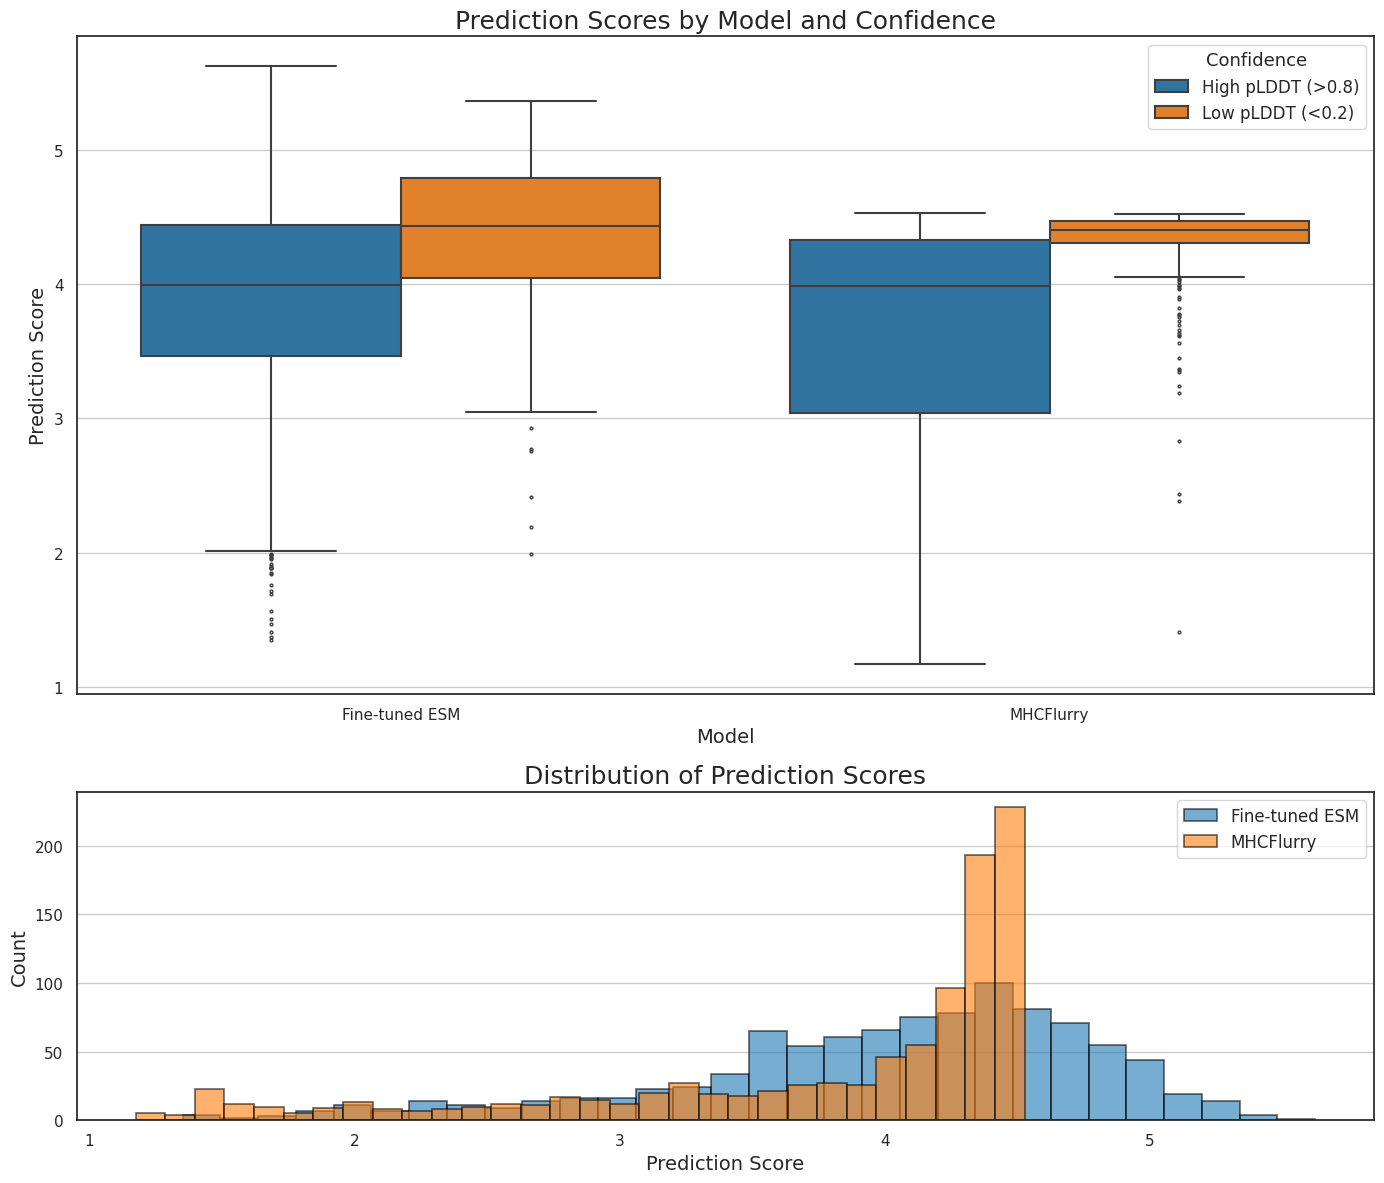

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_df already exists

# Subset high and low pLDDT groups
high_confidence = final_df[final_df['plddt'] > 0.8].copy()
low_confidence = final_df[final_df['plddt'] < 0.2].copy()

# Label them
high_confidence['Confidence'] = 'High pLDDT (>0.8)'
low_confidence['Confidence'] = 'Low pLDDT (<0.2)'

# Combine
plot_df = pd.concat([high_confidence, low_confidence], ignore_index=True)

# Melt the DataFrame to long format
plot_df_melted = plot_df.melt(
    id_vars=['HLA', 'Confidence'],
    value_vars=['prediction_x', 'mhc_log_y'],
    var_name='Model',
    value_name='Score'
)

# Map model names
model_name_map = {
    'prediction_x': 'Fine-tuned ESM',
    'mhc_log_y': 'MHCFlurry'
}
plot_df_melted['Model'] = plot_df_melted['Model'].map(model_name_map)

# ---------------------------
# Plot settings
sns.set_style('white')
colors = ['#1f77b4', '#ff7f0e']  # Default seaborn blue and orange

# Set up figure with gridspec (2 rows, 1 column)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})

# 1) BOX PLOT SIDE BY SIDE
sns.boxplot(
    data=plot_df_melted,
    x='Model',
    y='Score',
    hue='Confidence',
    palette=colors,
    fliersize=2,
    linewidth=1.5,
    ax=ax_box
)

# Outline boxes with black
for patch in ax_box.artists:
    patch.set_edgecolor('black')

ax_box.set_title('Prediction Scores by Model and Confidence', fontsize=18)
ax_box.set_xlabel('Model', fontsize=14)
ax_box.set_ylabel('Prediction Score', fontsize=14)
ax_box.legend(title='Confidence', fontsize=12, title_fontsize=13)
ax_box.grid(True, axis='y')

# 2) HISTOGRAM
# Separate histograms for Fine-tuned ESM and MHCFlurry
for idx, model in enumerate(['Fine-tuned ESM', 'MHCFlurry']):
    subset = plot_df_melted[plot_df_melted['Model'] == model]
    ax_hist.hist(
        subset['Score'],
        bins=30,
        alpha=0.6,
        label=model,
        color=colors[idx],
        edgecolor='black',
        linewidth=1.2
    )

ax_hist.set_title('Distribution of Prediction Scores', fontsize=18)
ax_hist.set_xlabel('Prediction Score', fontsize=14)
ax_hist.set_ylabel('Count', fontsize=14)
ax_hist.legend(fontsize=12)
ax_hist.grid(True, axis='y')

plt.tight_layout()
plt.show()


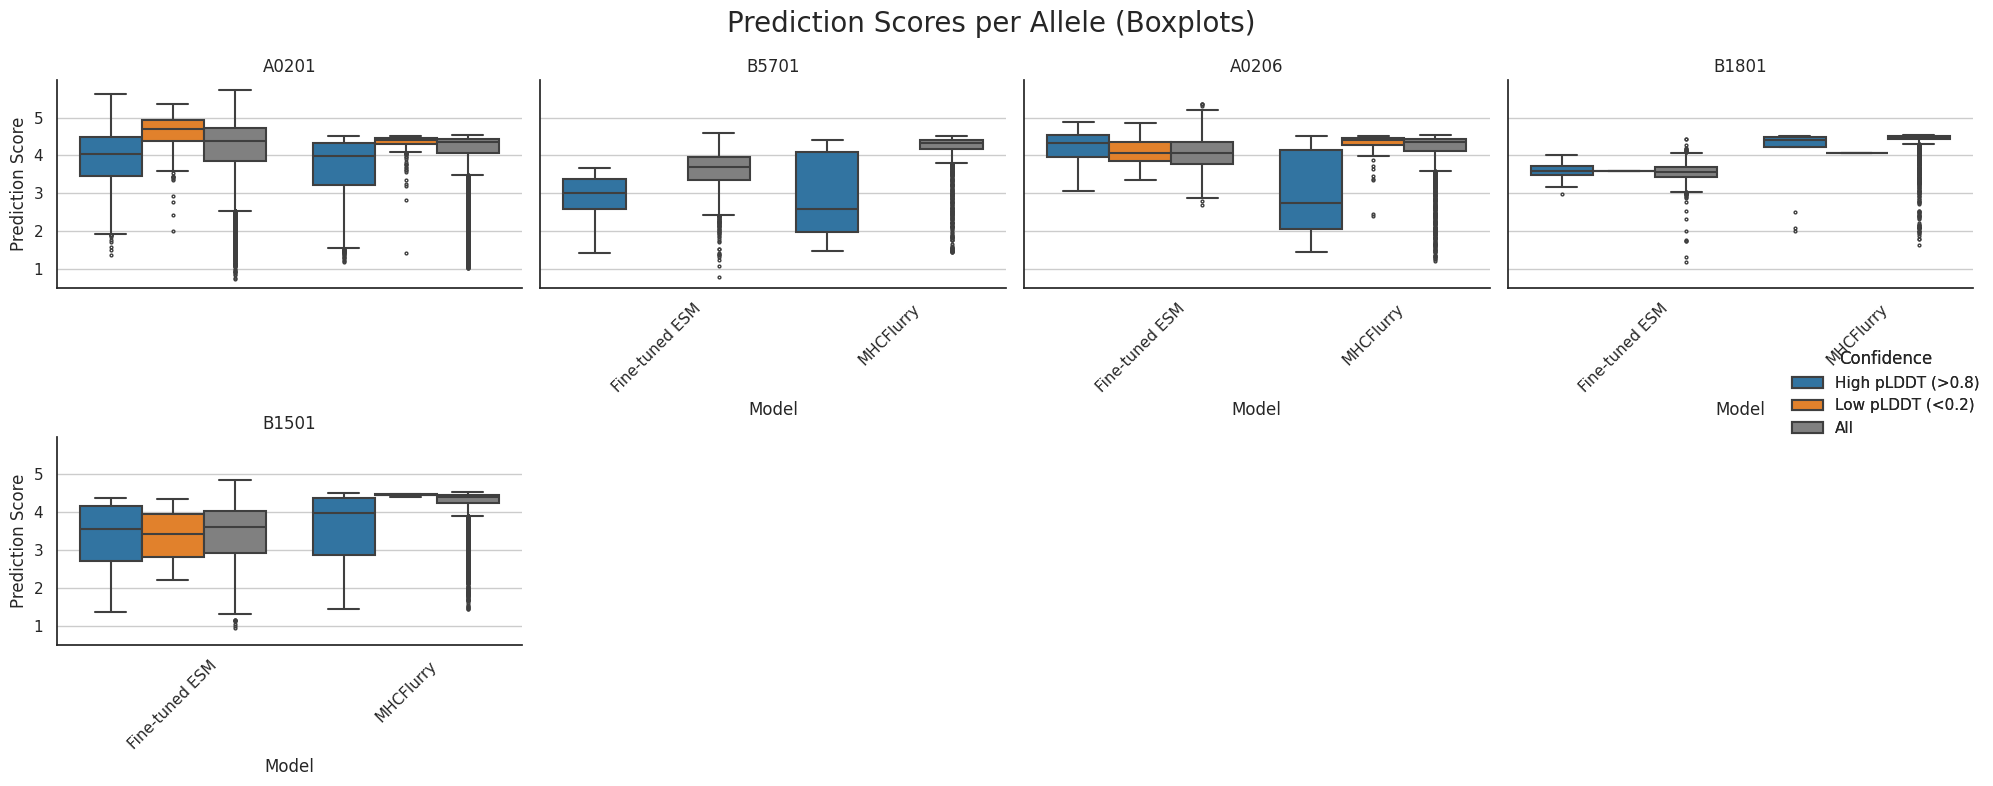

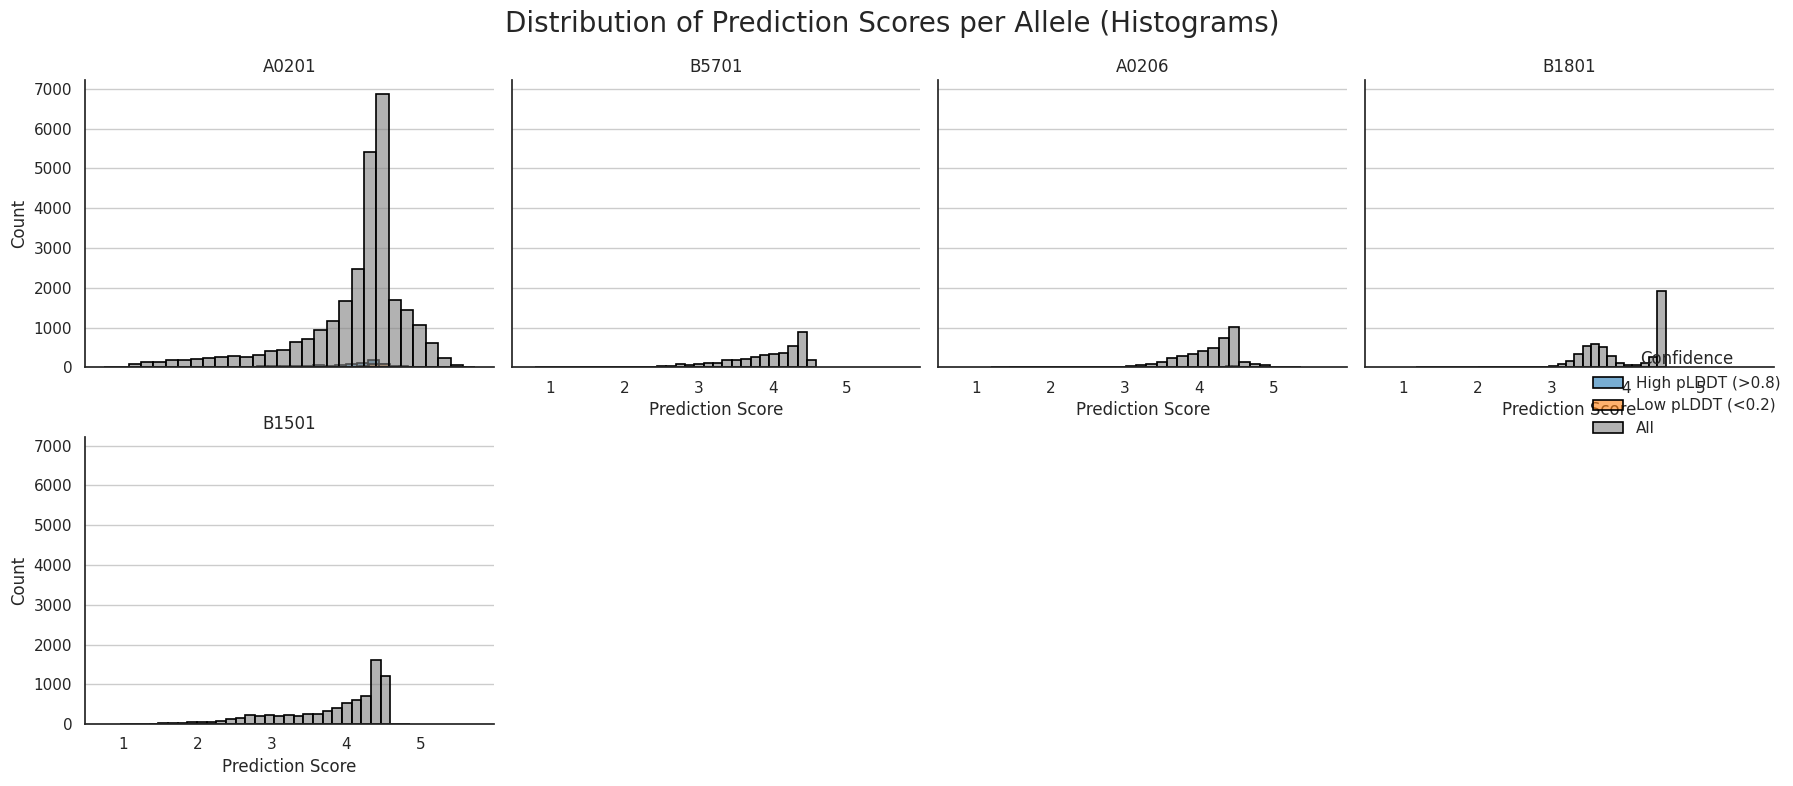

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_df already exists

# Subset high, low and all
high_confidence = final_df[final_df['plddt'] > 0.8].copy()
low_confidence = final_df[final_df['plddt'] < 0.2].copy()
all_data = final_df.copy()

# Label them
high_confidence['Confidence'] = 'High pLDDT (>0.8)'
low_confidence['Confidence'] = 'Low pLDDT (<0.2)'
all_data['Confidence'] = 'All'

# Combine
plot_df = pd.concat([high_confidence, low_confidence, all_data], ignore_index=True)

# Melt the DataFrame
plot_df_melted = plot_df.melt(
    id_vars=['HLA', 'Confidence'],
    value_vars=['prediction_x', 'mhc_log_y'],
    var_name='Model',
    value_name='Score'
)

# Map model names
model_name_map = {
    'prediction_x': 'Fine-tuned ESM',
    'mhc_log_y': 'MHCFlurry'
}
plot_df_melted['Model'] = plot_df_melted['Model'].map(model_name_map)

# ---------------------------
# Plot settings
sns.set_style('white')
colors = {
    'High pLDDT (>0.8)': '#1f77b4',  # blue
    'Low pLDDT (<0.2)': '#ff7f0e',   # orange
    'All': 'gray'                    # neutral gray
}

# =============================
# First: BOX PLOT per allele
# =============================

g = sns.catplot(
    data=plot_df_melted,
    x='Model',
    y='Score',
    hue='Confidence',
    col='HLA',
    kind='box',
    palette=colors,
    col_wrap=4,
    height=4,
    aspect=1,
    fliersize=2,
    linewidth=1.5,
    dodge=True
)

# Set black outline for boxes
for ax in g.axes.flatten():
    for patch in ax.artists:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgray')

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "Prediction Score")
g.add_legend(title='Confidence')
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Prediction Scores per Allele (Boxplots)', fontsize=20)

plt.tight_layout()
plt.show()

# =============================
# Second: HISTOGRAM per allele
# =============================

# Set up again
g2 = sns.FacetGrid(
    plot_df_melted,
    col='HLA',
    hue='Confidence',
    col_wrap=4,
    height=4,
    aspect=1,
    palette=colors
)

g2.map(
    sns.histplot,
    'Score',
    bins=30,
    kde=False,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.6
)

g2.add_legend(title='Confidence')
g2.set_axis_labels("Prediction Score", "Count")
g2.set_titles(col_template="{col_name}")
for ax in g2.axes.flatten():
    ax.grid(True, axis='y')

plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Distribution of Prediction Scores per Allele (Histograms)', fontsize=20)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --------------------------------------------
# 0 .  DataFrame setup
# --------------------------------------------
df = ESCMBA_predictions[ESCMBA_predictions['plddt'].notna()]   # <-- replace with your DataFrame
predictors = ['mpnn', 'plddt', 'i_ptm', 'i_pae', 'rmsd']
target = 'prediction_x'

# --------------------------------------------
# 1 .  SIMPLE (one-predictor) regressions
# --------------------------------------------
rows = []
for col in predictors:
    

    res = linregress(df[col].values, df[target].values)
    rows.append(
        {
            'predictor' : col,
            'slope'     : res.slope,
            'intercept' : res.intercept,
            'R²'        : res.rvalue**2,
            'p-value'   : res.pvalue
        }
    )

simple_summary = pd.DataFrame(rows).set_index('predictor')
print("\nOne-predictor regressions")
print(simple_summary)

# --------------------------------------------
# 2 .  MULTIPLE regression with all predictors
# --------------------------------------------
X = df[predictors].values
y = df[target].values
reg = LinearRegression().fit(X, y)

multi_summary = pd.DataFrame({
    'coef' : reg.coef_
}, index=predictors)
multi_summary.loc['intercept', 'coef'] = reg.intercept_

print("\nMultiple regression coefficients")
print(multi_summary)

print(f"\nMultiple-regression R²  : {r2_score(y, reg.predict(X)):.3f}")
print(f"Adjusted R²            : {1 - (1 - r2_score(y, reg.predict(X))) * (len(y)-1)/(len(y)-X.shape[1]-1):.3f}")


KeyError: 'plddt'

<Axes: xlabel='prediction_x', ylabel='mpnn'>

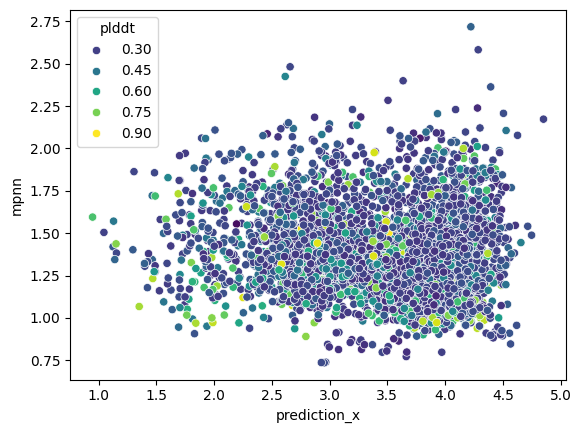

In [ ]:
sns.scatterplot(data = ESCMBA_predictions, y = 'mpnn', x ='prediction_x', hue = 'plddt', alpha =1, palette='viridis')

<Axes: xlabel='prediction_x', ylabel='plddt'>

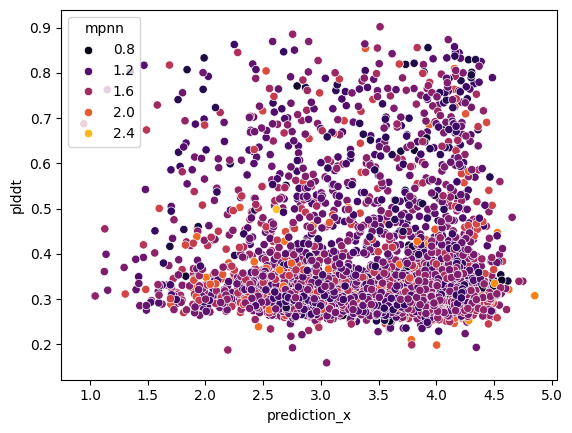

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'mpnn', alpha =1, palette='inferno')

<Axes: xlabel='prediction_x', ylabel='plddt'>

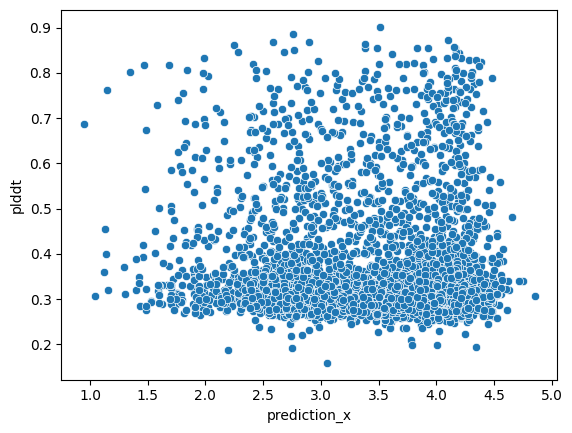

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x')

Text(0.5, 1.0, 'RFdiffusion generated peptides with MHC structure fixed.')

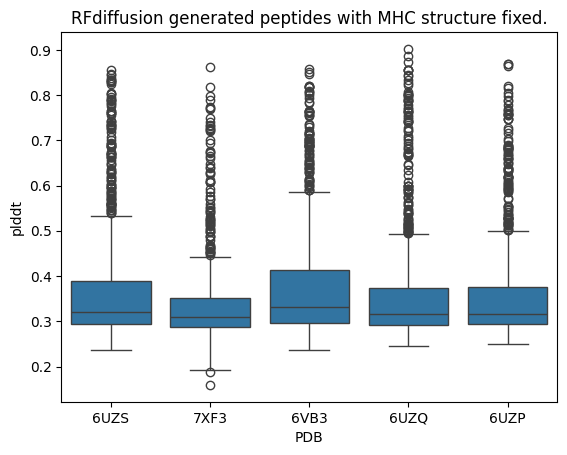

In [ ]:
sns.boxplot(data = ESCMBA_predictions, y = 'plddt', x ='PDB') #, palette='viridis')
plt.title("RFdiffusion generated peptides with MHC structure fixed.")

<Axes: xlabel='PDB', ylabel='prediction_x'>

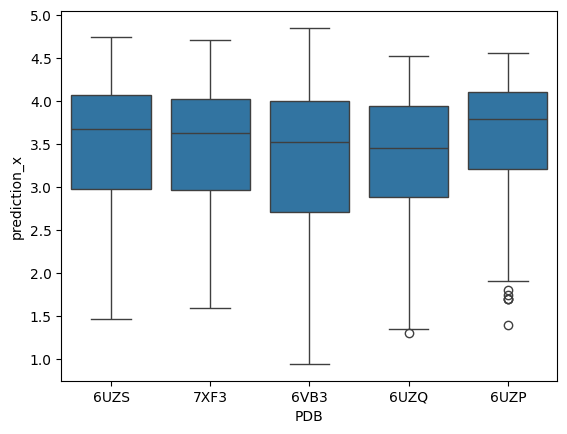

In [ ]:
sns.boxplot(data = ESCMBA_predictions, y = 'prediction_x', x ='PDB') #, palette='viridis')

<Axes: xlabel='prediction_x', ylabel='plddt'>

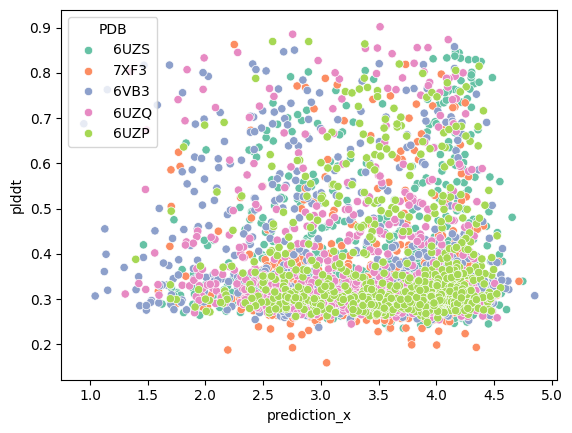

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'PDB', palette='Set2')

<Axes: xlabel='prediction_x', ylabel='plddt'>

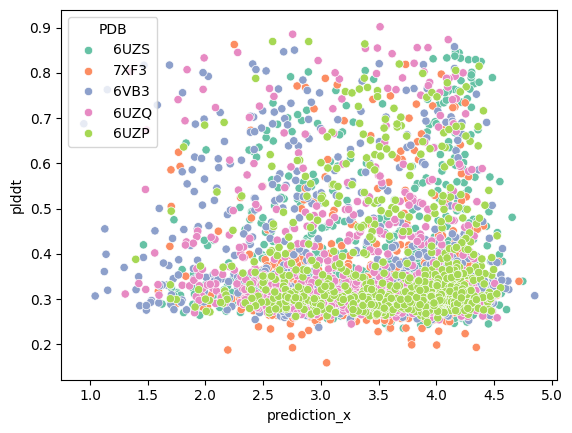

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'PDB', palette='Set2')

In [ ]:
mhc_epitope_contacts = pd.read_csv("mhc_epitope_contacts.csv")

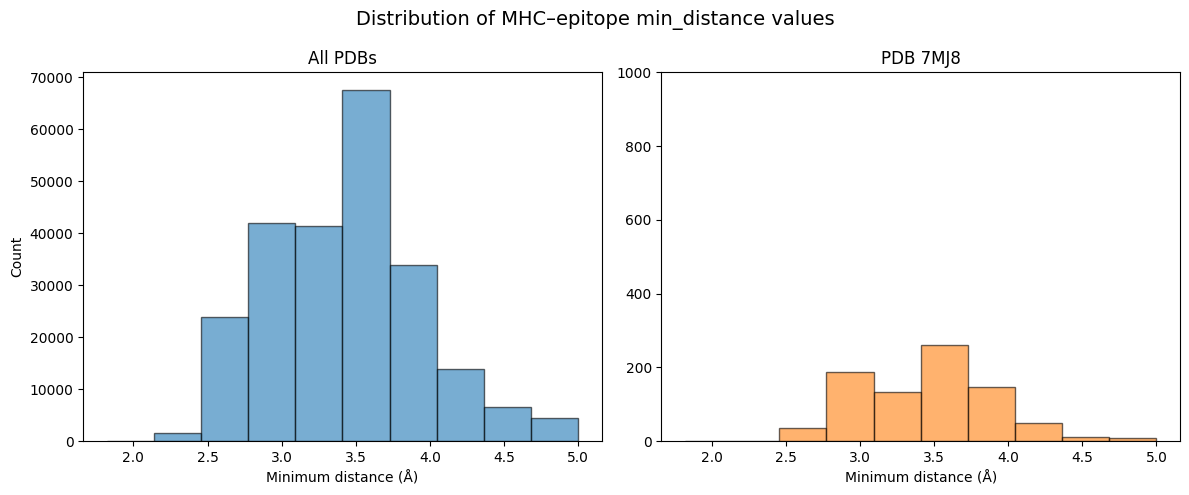

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- data ----------
all_vals    = mhc_epitope_contacts['min_distance'].dropna()
subset_vals = mhc_epitope_contacts.loc[
    mhc_epitope_contacts['pdb_id'] == '7KGQ', 'min_distance'
].dropna()

# consistent binning so the x-axes line up
bins = np.histogram_bin_edges(all_vals)

# ---------- plotting ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# panel 1 – all PDBs
axes[0].hist(all_vals,
             bins=bins,
             edgecolor='black',
             alpha=0.6)
axes[0].set_title('All PDBs')
axes[0].set_xlabel('Minimum distance (Å)')
axes[0].set_ylabel('Count')
# axes[0].set_ylim(0, 1000)      # same y-scale for easy comparison

# panel 2 – 7MJ8 only
axes[1].hist(subset_vals,
             bins=bins,
             edgecolor='black',
             alpha=0.6,
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])  # second default color
axes[1].set_title('PDB 7MJ8')
axes[1].set_xlabel('Minimum distance (Å)')
axes[1].set_ylim(0, 1000)

fig.suptitle('Distribution of MHC–epitope min_distance values', fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
pdb_chain_summary = pd.read_csv("pdb_chain_summary.csv").drop_duplicates()

In [ ]:
# Count chains per PDB
chain_counts = pdb_chain_summary.groupby('pdb_id').size().reset_index(name='num_chains')

# Filter to PDBs that have exactly 3 chains
three_chain_pdbs = chain_counts[chain_counts['num_chains'] == 3].sort_values(by='num_chains', ascending=False)


In [ ]:
# Filter the full chain summary to only 3-chain PDBs
filtered_summary = pdb_chain_summary[pdb_chain_summary['pdb_id'].isin(three_chain_pdbs['pdb_id'])]

In [ ]:

interactions = mhc_epitope_contacts.drop_duplicates().reset_index(drop=True)
# 1. Count how many distinct epitope residues contact each MHC residue
contact_counts = interactions.groupby(['mhc_chain', 'mhc_resnum'])['epitope_resnum'].nunique().reset_index()
contact_counts = contact_counts.rename(columns={'epitope_resnum': 'contact_count'})

# 2. Merge back into original interaction DataFrame
interactions = interactions.merge(contact_counts, on=['mhc_chain', 'mhc_resnum'], how='left')

# 3. Assign importance tier based on contact count
interactions["importance"] = interactions["contact_count"].map(
    lambda x: "core_hotspot" if x >= 4 else
              "high_contact" if x == 3 else
              "medium_contact" if x == 2 else
              "low_contact"
)


In [ ]:
job_params = []

# Only include PDBs with exactly 3 chains
chain_counts = filtered_summary.groupby('pdb_id').size()
three_chain_pdbs = chain_counts[chain_counts == 3].index.tolist()

for pdb_id in three_chain_pdbs:
    chains_df = filtered_summary[filtered_summary['pdb_id'] == pdb_id]
    chains = ",".join(chains_df['chain_id'].tolist())
    
    # Determine epitope chain: the one with smallest num_residues
    ep_chain = chains_df.loc[chains_df['num_residues'].idxmin(), 'chain_id']
    
    # Collect hotspot residues (core + high + medium)
    inter_df = interactions[
        (interactions['pdb_id'] == pdb_id) &
        (interactions['epitope_chain'] == ep_chain) &
        (interactions['importance'].isin(['core_hotspot','high_contact','medium_contact']))
    ]
    hotspots = sorted({f"{row['mhc_chain']}{row['mhc_resnum']}" for _, row in inter_df.iterrows()})

    if len(hotspots) < 5:
        inter_df = interactions[
            (interactions['pdb_id'] == pdb_id) &
            (interactions['epitope_chain'] == ep_chain) &
            (interactions['importance'].isin(['high_contact','medium_contact']))
        ]
    
    job_params.append({
        'pdb_id': pdb_id,
        'chains': chains,
        'epitope_chain': ep_chain,
        'hotspots': ",".join(hotspots)
    })

df_job_params = pd.DataFrame(job_params)

for _, row in df_job_params.iterrows():
    # get chain lengths for contigs construction
    lengths = {
        ch: filtered_summary.query(f"pdb_id=='{row.pdb_id}' & chain_id=='{ch}'").num_residues.item()
        for ch in row.chains.split(",")
    }
    # build contigs string
    parts = []
    for ch, L in lengths.items():

        if ch == row.epitope_chain:
            
            LENGTH = np.random.randint(7,13)
            L = LENGTH

            parts.append(f"0/{L}")
        else:
            parts.append(f"{ch}1-{L}/0")
    full_contigs = " ".join(parts)

In [ ]:
df_job_params['n_hospots'] = df_job_params['hotspots'].apply(lambda x: len(x.split(",")))

In [ ]:
df_job_params[df_job_params['pdb_id'] == '7KGQ']

,pdb_id,chains,epitope_chain,hotspots,n_hospots
74,7KGQ,"A,B,C",C,"A114,A116,A123,A124,A143,A146,A147,A150,A152,A...",50


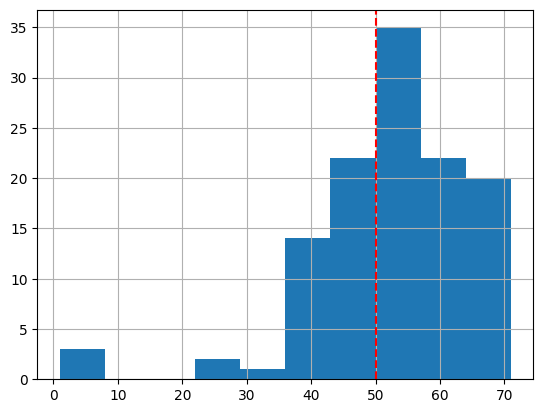

In [ ]:
df_job_params['n_hospots'].hist()
#veritcal line in the histogram
plt.axvline(x=50, color='r', linestyle='--')

In [ ]:
rfd_peptides['CREATED'] = rfd_peptides['CREATED'].str.split(" ", expand=True)[0]

<Axes: xlabel='CREATED', ylabel='plddt'>

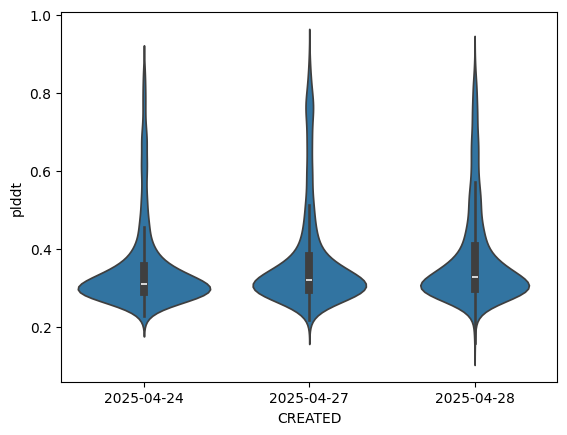

In [ ]:
sns.violinplot(data = rfd_peptides.sort_values(by='CREATED'), x = 'CREATED', y= 'plddt') #, palette='viridis')